In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

### Part 1: Data Exploration

### Objective
This section explores data structure, missing values and category distributions
to identify potential data quality issues.

In [2]:
df_accounts = pd.read_json('accounts_anonymized.json')
df_accounts.head()

,account_sfid,account_name,account_created_date,account_country,account_industry
0,28cb93e07db33a85d12c75825a11ab6a97c5a0df9750f6...,Customer_b9c711e0,2017-12-18 15:53:15,Pakistan,Printing
1,17779701277914218bcfcd9211c3fb6673758ca2f6e014...,Customer_b3e69ecd,2010-01-11 17:41:46,United Kingdom,Household & Personal Products
2,777c8f6154d9e1c1563ce0a62dbd8392ef3204cec6ecd1...,Customer_3b6e1b44,2020-10-19 17:12:22,China,Packaging and Containers
3,e7b6a33c931f01e1e2d42b47318945216da6fef294a738...,Customer_58de6751,2019-03-20 12:56:09,South Korea,Pharmaceuticals
4,fbcec0b147243cfce96df94fe543968c04cfc0a4a29fd7...,Customer_97f3101d,2021-03-24 14:06:24,Poland,Printing


In [3]:
df_support = pd.read_json('support_cases_anonymized.json')
df_support.head()

,case_sfid,account_sfid,case_number,case_contact_name,case_product,case_status,case_resolution,case_details,case_closure,case_priority,case_severity,case_reason,case_type,case_category,case_created_date,case_closed_date
0,c9f05bc582a8abec4c5f1a9385c24a96d86d3f3093c557...,58912bf7e5131400adbc1c1521158b7b8cc2f2f3fbd51f...,69908,Contact_e2737240,Verify Enterprise,Closed,Done,Trial,Undefined,Normal,Medium,Other,License Activation,Licensing,2025-01-09,2025-01-09
1,a8f7c39a437d713e800599205d6cd9319733fd5df18af8...,3675a0565672bccecbba8a8a102b0482f3c82e6f07443e...,69887,Contact_20439d47,GVD Perpetual,Closed,Done,Trial,Undefined,Normal,Low,Other,License Activation,Licensing,2025-01-09,2025-01-09
2,654dd0c826e0842cdd030e935aa1e886787cb990b693c2...,58912bf7e5131400adbc1c1521158b7b8cc2f2f3fbd51f...,69910,Contact_edf7784e,Verify Enterprise,Closed,Done,Trial,Undefined,Normal,Low,Other,License Activation,Licensing,2025-01-09,2025-01-09
3,57422ac55031dd6c7acf36a2bc6d74e01e0c0194c61318...,908d42c9a4e3f4beae8bf394dd2ed82090a219cdf64518...,69905,Contact_6f59abbf,Verify,Closed,Done,Full,Undefined,Normal,Medium,Other,License Activation,Licensing,2025-01-09,2025-01-09
4,b88c12d55a7c468c96e48a7693e306e24f44947f5f1e3f...,None,69891,Contact_f02dfb7d,Other,New,Undefined,Undefined,Undefined,Normal,Undefined,Other,Undefined,Undefined,2025-01-09,None


In [4]:
df_accounts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1415 entries, 0 to 1414
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   account_sfid          1415 non-null   object
 1   account_name          1415 non-null   object
 2   account_created_date  1415 non-null   object
 3   account_country       1408 non-null   object
 4   account_industry      1402 non-null   object
dtypes: object(5)
memory usage: 55.4+ KB


In [5]:
df_accounts['account_sfid'].nunique()

1415

In [6]:
df_accounts['account_country'].nunique()

72

In [7]:
df_accounts['account_country'].value_counts().head(10)

account_country
United States     553
China              73
Canada             68
India              60
United Kingdom     51
Germany            49
Spain              47
South Korea        45
France             33
Brazil             28
Name: count, dtype: int64

In [8]:
df_accounts['account_industry'].value_counts().head(10)

account_industry
Pharmaceuticals                  421
Printing                         265
Packaging and Containers         252
Household & Personal Products     86
Food & Beverage                   78
Advertising & Branding Agency     66
Medical Devices                   60
Other                             56
Information Technology            29
Chemicals                         27
Name: count, dtype: int64

In [9]:
df_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   case_sfid          10000 non-null  object
 1   account_sfid       8407 non-null   object
 2   case_number        10000 non-null  int64 
 3   case_contact_name  10000 non-null  object
 4   case_product       10000 non-null  object
 5   case_status        10000 non-null  object
 6   case_resolution    10000 non-null  object
 7   case_details       10000 non-null  object
 8   case_closure       10000 non-null  object
 9   case_priority      10000 non-null  object
 10  case_severity      10000 non-null  object
 11  case_reason        10000 non-null  object
 12  case_type          10000 non-null  object
 13  case_category      10000 non-null  object
 14  case_created_date  10000 non-null  object
 15  case_closed_date   9058 non-null   object
dtypes: int64(1), object(15)
memory usage: 1.2

In [10]:
df_support['case_sfid'].nunique()

10000

In [11]:
df_support['account_sfid'].nunique()

1415

In [12]:
set(df_accounts['account_sfid']) - set(df_support['account_sfid'])
## Verifying if the accounts in both datasets are the same

set()

In [13]:
df_support['account_sfid'].value_counts().head(10)

account_sfid
87b5772b6964f23ef7db8085e8f91c41937979575f8afdfa63b4b1c3948e4fce    1650
0e45934f296ca9a462fb43e3d47246ced1379555d4eb3e362193b30d7f56058e     226
a6b6a3deac72bfbd98608d35a5c4d165e05ff0a89debb281b35fcaa665e47a8d     165
1a179a8a319d12ad422050acbdc3866347a5e629d56090732f873db22ff86c08     107
e2494728998b67f23f0e57ef2441feb32e15911b3c9f13e2dda5dc4475528a10      73
8abdacb4cd487937795128cbb3945afac68c05b1c01751b93955ae28be924b60      62
40eddc24fc14e8fbe2ac53610b01763b4bba73e21136f87b83a65742e5a1e21a      62
7712e7fdc054bb705fdcebff00811739b91b8462d03b3aa7bda4b6a84dbc5901      58
bf88e3b3e69d81248b95f211c8f5ee632e33d731e09058f8649f3f4ff99e7ee5      56
1bd74340189c9977c77bbee142cd0f06e376924c6934b51fe0126b873d315e9b      54
Name: count, dtype: int64

There is an account responsible over 1500 of the support cases, the number may be even higher considering that there is significant missing data in the `account_sfid` column in the support_cases_anonymized dataset

In [14]:
df_support['case_product'].value_counts().head(10)

case_product
GVD                   2850
Other                 2573
Verify                1028
Not a Support Case    1024
GVW                    825
Esko                   356
Verify Enterprise      231
GVD Enterprise         176
GVD Perpetual          156
Print Inspection       148
Name: count, dtype: int64

In [15]:
df_support['case_status'].value_counts().head(10)

case_status
Closed                      7043
Duplicate                   2015
New                          795
Waiting On Customer           45
Working                       39
Sent_To_Dev                   35
Waiting for 3rd Party         10
Remote Session Scheduled       9
Assigned                       9
Name: count, dtype: int64

In [16]:
df_support['case_resolution'].value_counts().head(10)

case_resolution
Undefined               4064
Done                    3304
Fixed                   1413
No Customer Response     768
Known Issue              168
Cancelled                150
Cannot Reproduce          79
Training Provided         53
Custom Profile             1
Name: count, dtype: int64

In [17]:
df_support['case_details'].value_counts().head(10)

case_details
Undefined                       4591
Full                            1831
Module Affected: Application    1111
Trial                            750
Module Affected: Graphics        384
Modification                     373
Module Affected: Text            275
Module Affected: Barcode         170
Online                           161
Report                            66
Name: count, dtype: int64

In [18]:
df_support['case_closure'].value_counts().head(10)

case_closure
Undefined    10000
Name: count, dtype: int64

This column has every single value as 'Unknown'

In [19]:
df_support['case_priority'].value_counts().head(10)

case_priority
Normal          9811
Urgent           152
not_priority      35
High               2
Name: count, dtype: int64

In [20]:
df_support['case_severity'].value_counts().head(10)

case_severity
Medium       4078
Low          3159
Undefined    2659
High           72
Urgent         32
Name: count, dtype: int64

In [21]:
df_support['case_reason'].value_counts().head(10)

case_reason
Other                  9995
Inspection Problem        2
Software Activation       1
User Activation           1
Software Problem          1
Name: count, dtype: int64

This column also has almost no variability in its values

In [22]:
df_support['case_type'].value_counts().head(10)

case_type
Undefined               3728
License Activation      2963
Software Question        720
Software Performance     708
User Access Issue        623
Inspection Results       430
License Issue            226
Crash                    195
Hardware Question         96
Bug                       94
Name: count, dtype: int64

In [23]:
df_support['case_category'].value_counts().head(10)

case_category
Licensing                 3847
Undefined                 3635
Software                  2204
Hardware                   183
Server & Configuration      49
Order Services              48
Not a Support Case          34
Name: count, dtype: int64

In [24]:
df_support.groupby(
    df_support['account_sfid'].isna()
)['case_status'].value_counts(normalize=True)

account_sfid  case_status             
False         Closed                      0.837754
              Duplicate                   0.135720
              New                         0.009516
              Waiting On Customer         0.005353
              Sent_To_Dev                 0.004163
              Working                     0.004163
              Waiting for 3rd Party       0.001189
              Assigned                    0.001071
              Remote Session Scheduled    0.001071
True          Duplicate                   0.548650
              New                         0.448839
              Working                     0.002511
Name: proportion, dtype: float64

No case without account_sfid is Closed

In [25]:
closed_or_duplicate = df_support['case_status'].isin(['Closed', 'Duplicate'])
has_date = df_support['case_closed_date'].notna()

(closed_or_duplicate == has_date).all()

## Verifying if every case that is either not closed or duplicated has no close date

np.True_

In [26]:
df_accounts.fillna({'account_country': 'Unknown'}, inplace=True)
df_accounts.fillna({'account_industry': 'Unknown'}, inplace=True)

In [27]:
df_accounts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1415 entries, 0 to 1414
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   account_sfid          1415 non-null   object
 1   account_name          1415 non-null   object
 2   account_created_date  1415 non-null   object
 3   account_country       1415 non-null   object
 4   account_industry      1415 non-null   object
dtypes: object(5)
memory usage: 55.4+ KB


In [28]:
df_support = df_support.drop(['case_closure'], axis = 1)
df_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   case_sfid          10000 non-null  object
 1   account_sfid       8407 non-null   object
 2   case_number        10000 non-null  int64 
 3   case_contact_name  10000 non-null  object
 4   case_product       10000 non-null  object
 5   case_status        10000 non-null  object
 6   case_resolution    10000 non-null  object
 7   case_details       10000 non-null  object
 8   case_priority      10000 non-null  object
 9   case_severity      10000 non-null  object
 10  case_reason        10000 non-null  object
 11  case_type          10000 non-null  object
 12  case_category      10000 non-null  object
 13  case_created_date  10000 non-null  object
 14  case_closed_date   9058 non-null   object
dtypes: int64(1), object(14)
memory usage: 1.1+ MB


In this exploratory data analysis, several relevant insights were identified across the datasets:

* A small number of missing values were found in two categorical columns of the accounts dataset. These values were replaced with 'Unknown' to preserve the records and maintain categorical consistency.

* A significant number of missing values were observed in the `account_sfid` field within the support cases dataset. However, further analysis showed that these cases are predominantly associated with `New` or `Duplicate` statuses, and no closed cases were found without an associated `account_sfid`.

* The missing values in the `case_closed_date` represent cases that are not closed yet

* One account was identified with over 1,500 support cases, indicating a potential outlier and a strong concentration of support demand.

* The `case_closure` column was removed from the analysis due to zero variance, as all entries contained the same value, rendering the column non-informative.


### Part 2: Data Processing

### Objective

The objective of this section is to join the datasets using SQL and derive aggregated metrics that provide insight into support demand, case distribution, and account-level concentration.

In [29]:
conn = sqlite3.connect(':memory:')

In [30]:
df_accounts.to_sql('accounts', conn, index=False, if_exists='replace')
df_support.to_sql('support', conn, index=False, if_exists='replace')

10000

In [31]:
query_create_view = """
    CREATE VIEW accounts_and_support AS
    SELECT s.*, a.account_country, a.account_industry
    FROM support s LEFT JOIN accounts a
    ON s.account_sfid = a.account_sfid;
"""
## Creating a view with the datasets already joined in case we need informations from both of the datasets for a metric

conn.execute(query_create_view)

In [32]:
query = """
    SELECT COUNT(*) AS total_cases
    FROM support
"""
total_cases = pd.read_sql_query(query, conn)
total_cases

,total_cases
0,10000


In [33]:
query = """
    SELECT
    COUNT(*) AS cases_without_account
    FROM support
    WHERE account_sfid IS NULL
"""
cases_without_account = pd.read_sql_query(query, conn)
cases_without_account

,cases_without_account
0,1593


### Case Volume Metrics

The following queries analyze the distribution of support cases across
accounts, countries, and products to identify concentration patterns
and high-demand segments.

In [34]:
query = """
    SELECT account_sfid, COUNT(*) AS total_cases
    FROM support
    WHERE account_sfid IS NOT NULL
    GROUP BY account_sfid
    ORDER BY total_cases DESC
    LIMIT 10
"""

top10_accounts = pd.read_sql_query(query, conn)
top10_accounts

,account_sfid,total_cases
0,87b5772b6964f23ef7db8085e8f91c41937979575f8afd...,1650
1,0e45934f296ca9a462fb43e3d47246ced1379555d4eb3e...,226
2,a6b6a3deac72bfbd98608d35a5c4d165e05ff0a89debb2...,165
3,1a179a8a319d12ad422050acbdc3866347a5e629d56090...,107
4,e2494728998b67f23f0e57ef2441feb32e15911b3c9f13...,73
5,8abdacb4cd487937795128cbb3945afac68c05b1c01751...,62
6,40eddc24fc14e8fbe2ac53610b01763b4bba73e21136f8...,62
7,7712e7fdc054bb705fdcebff00811739b91b8462d03b3a...,58
8,bf88e3b3e69d81248b95f211c8f5ee632e33d731e09058...,56
9,6bad06c3c7f2472ded28a5f783103f751ad31b80137837...,54


In [35]:
query = """
    SELECT account_country, COUNT(*) AS total_cases
    FROM accounts_and_support
    GROUP BY account_country
    HAVING COUNT(*) >=10
    ORDER BY total_cases DESC;
"""

cases_per_country = pd.read_sql_query(query, conn)
cases_per_country.head()

,account_country,total_cases
0,United States,3383
1,Canada,1967
2,None,1593
3,China,399
4,India,251


In [36]:
query = """
    SELECT case_status, COUNT(*) AS total_cases
    FROM support
    GROUP BY case_status
    ORDER BY total_cases DESC;
"""

cases_per_status = pd.read_sql_query(query, conn)
cases_per_status.head()

,case_status,total_cases
0,Closed,7043
1,Duplicate,2015
2,New,795
3,Waiting On Customer,45
4,Working,39


In [37]:
query = """
    SELECT case_product, COUNT(*) AS total_cases
    FROM support
    GROUP BY case_product
    HAVING COUNT(*) >=10
    ORDER BY total_cases DESC;
"""

cases_per_product = pd.read_sql_query(query, conn)
cases_per_product.head()

,case_product,total_cases
0,GVD,2850
1,Other,2573
2,Verify,1028
3,Not a Support Case,1024
4,GVW,825


### Close rate metrics

Close rate metrics were calculated only for categories with enough cases
to avoid misleading results.

In [38]:
query = """
    SELECT SUM(CASE WHEN case_status = "Closed" THEN 1 ELSE 0 END)*1.0/COUNT(*) AS close_rate
    FROM support
"""

close_rate = pd.read_sql_query(query, conn)
close_rate

,close_rate
0,0.7043


In [39]:
query = """
    SELECT case_product, SUM(CASE WHEN case_status = "Closed" THEN 1 ELSE 0 END)*1.0/COUNT(*) AS close_rate
    FROM support
    WHERE case_category <> 'Not a Support Case'
    GROUP BY case_product
    HAVING COUNT(*) >= 10
    ORDER BY close_rate DESC
"""

close_rate_per_product = pd.read_sql_query(query, conn)
close_rate_per_product

,case_product,close_rate
0,Text Inspection,1.000000
1,ScanProof? Proof-Reader Workstation License (...,1.000000
2,Platform for Digital Bundle,1.000000
3,Graphics Inspection,1.000000
4,GVD Profile Editor,1.000000
5,GVD Lite,1.000000
6,Complete Platform Bundle,1.000000
7,C8 Cylinder Scanner,1.000000
8,Print Inspection,0.993243
9,Verify Enterprise,0.991342


In [40]:
query = """
    SELECT case_severity, COUNT(*) as total_cases, SUM(CASE WHEN case_status = "Closed" THEN 1 ELSE 0 END)*1.0/COUNT(*) AS close_rate
    FROM support
    GROUP BY case_severity
    HAVING COUNT(*) >= 10
    ORDER BY close_rate DESC
"""
close_rate_per_severity = pd.read_sql_query(query, conn)
close_rate_per_severity

,case_severity,total_cases,close_rate
0,Urgent,32,1.000000
1,Low,3159,0.969611
2,Medium,4078,0.951937
3,High,72,0.916667
4,Undefined,2659,0.000000


In [41]:
query = """
    SELECT case_type, SUM(CASE WHEN case_status = "Closed" THEN 1 ELSE 0 END)*1.0/COUNT(*) AS close_rate
    FROM support
    GROUP BY case_type
    HAVING COUNT(*) >= 10
    ORDER BY close_rate DESC
"""
close_rate_per_type = pd.read_sql_query(query, conn)
close_rate_per_type

,case_type,close_rate
0,Connection Issue,1.000000
1,Crash,0.979487
2,Software Question,0.970833
3,License Activation,0.969963
4,Feature request,0.966667
5,User Access Issue,0.966292
6,Software Performance,0.951977
7,Network,0.950000
8,License Issue,0.942478
9,Hardware Question,0.937500


In [42]:
query = """
    SELECT account_country, SUM(CASE WHEN case_status = "Closed" THEN 1 ELSE 0 END)*1.0/COUNT(*) AS close_rate
    FROM accounts_and_support
    GROUP BY account_country
    HAVING COUNT(*) >= 10
    ORDER BY close_rate DESC
"""
close_rate_per_country = pd.read_sql_query(query, conn)
close_rate_per_country

,account_country,close_rate
0,Unknown,1.000000
1,New Zealand,1.000000
2,Netherlands,1.000000
3,Lithuania,1.000000
4,Dominican Republic,1.000000
5,Denmark,1.000000
6,Czech Republic,1.000000
7,Costa Rica,1.000000
8,Austria,1.000000
9,Argentina,1.000000


In [43]:
query = """
    SELECT SUM(CASE WHEN case_status = "Duplicate" THEN 1 ELSE 0 END)*1.0/COUNT(*) AS duplicate_rate
    FROM support
"""
duplicate_rate = pd.read_sql_query(query, conn)
duplicate_rate

,duplicate_rate
0,0.2015


In [44]:
query = """
    WITH ranked_accounts AS (
    SELECT
        account_sfid,
        COUNT(*) AS total_cases
    FROM support
    WHERE account_sfid IS NOT NULL
    GROUP BY account_sfid
    ),
    totals AS (
    SELECT SUM(total_cases) AS grand_total FROM ranked_accounts
    )
    SELECT
    SUM(total_cases) * 1.0 / (SELECT grand_total FROM totals)
        AS pct_cases_top_accounts
    FROM (
    SELECT total_cases
    FROM ranked_accounts
    ORDER BY total_cases DESC
    LIMIT 5
    )
"""

pct_cases_top_accounts = pd.read_sql_query(query, conn)
pct_cases_top_accounts

,pct_cases_top_accounts
0,0.264185


This result highlights a strong concentration of support demand among a small
number of accounts, suggesting opportunities for targeted investigation or
preventive actions.

In this section, several metrics were designed to generate insights and define key KPIs. These metrics helped provide value by:

* Understanding the nature of support demand, including which accounts generate the most support cases, which products are most frequently associated with support requests, and the countries from which these accounts originate.

* Evaluating case resolution performance through metrics such as close rate, including breakdowns by relevant attributes. This provides insight into how efficiently the company resolves support cases and where potential challenges may exist.

* Identifying concentration of support demand at the account level, with approximately 26% of all support cases originating from just five accounts.


### Part 3: Data visualization

### Objective

This section presents visual representations of the key metrics derived in the previous SQL analysis. The goal is to highlight patterns, concentrations, and performance indicators in a clear and intuitive way.

### Distribution of Support Cases

The following visualizations show how support cases are distributed across accounts, and status, helping identify concentration patterns and high-demand segments.


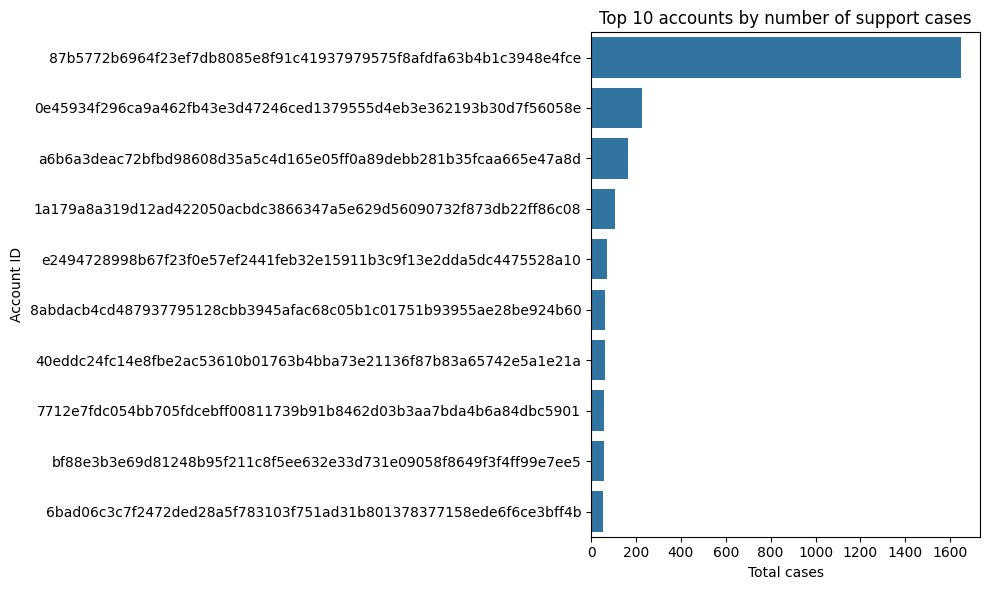

In [61]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top10_accounts,
    x='total_cases',
    y='account_sfid'
)

plt.title('Top 10 accounts by number of support cases')
plt.xlabel('Total cases')
plt.ylabel('Account ID')

plt.tight_layout()
plt.show()

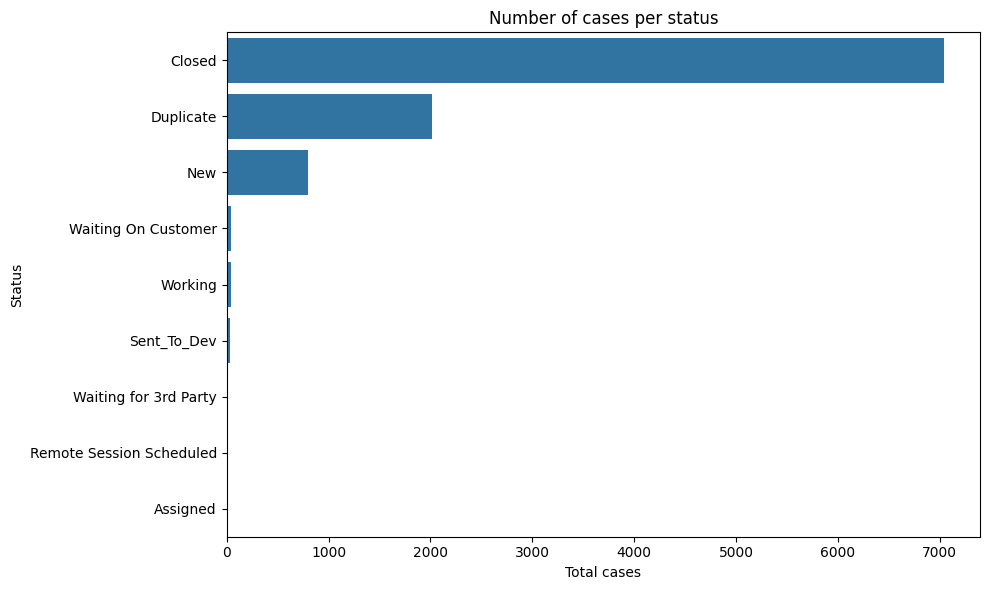

In [62]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=cases_per_status,
    x='total_cases',
    y='case_status'
)

plt.title('Number of cases per status')
plt.xlabel('Total cases')
plt.ylabel('Status')

plt.tight_layout()
plt.show()

### Case Resolution Performance

These visualizations focus on resolution performance metrics, such as close rate,
to assess how effectively support cases are being resolved across different
dimensions.

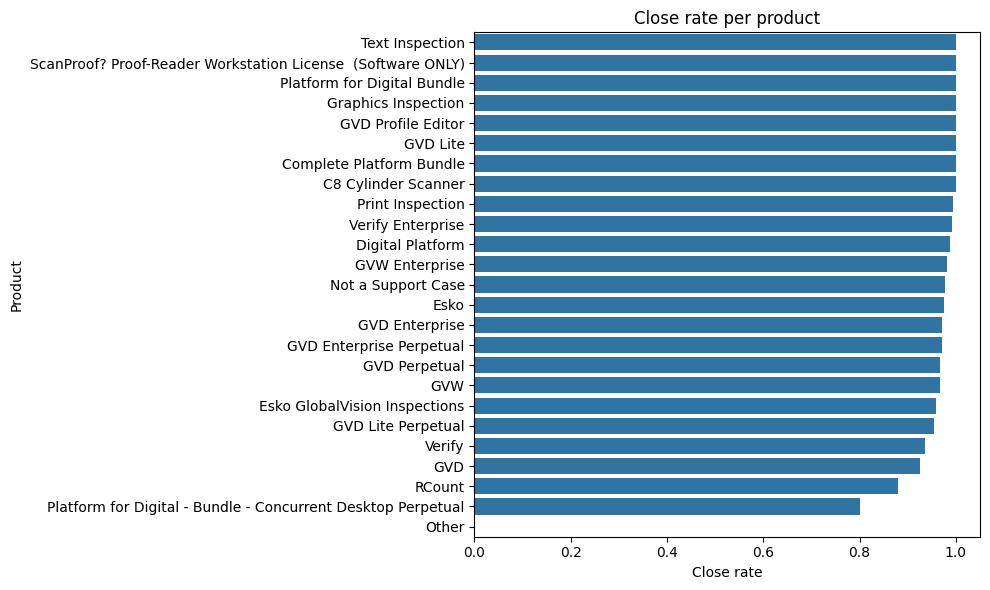

In [63]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=close_rate_per_product,
    x='close_rate',
    y='case_product'
)

plt.title('Close rate per product')
plt.xlabel('Close rate')
plt.ylabel('Product')

plt.tight_layout()
plt.show()

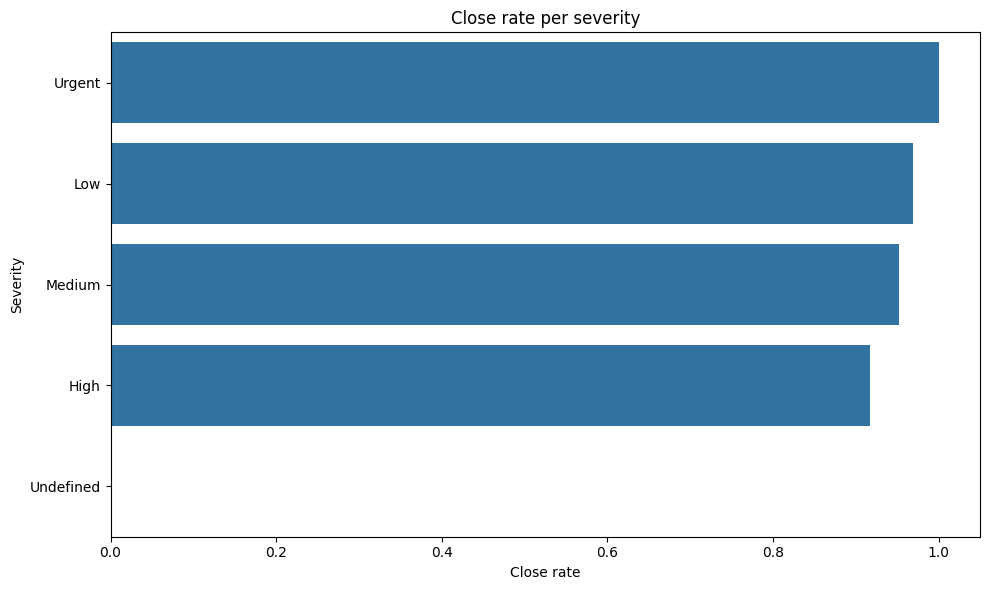

In [64]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=close_rate_per_severity,
    x='close_rate',
    y='case_severity'
)

plt.title('Close rate per severity')
plt.xlabel('Close rate')
plt.ylabel('Severity')

plt.tight_layout()
plt.show()

### Account-Level Concentration

This visualization highlights the concentration of support demand among the
accounts with the hig

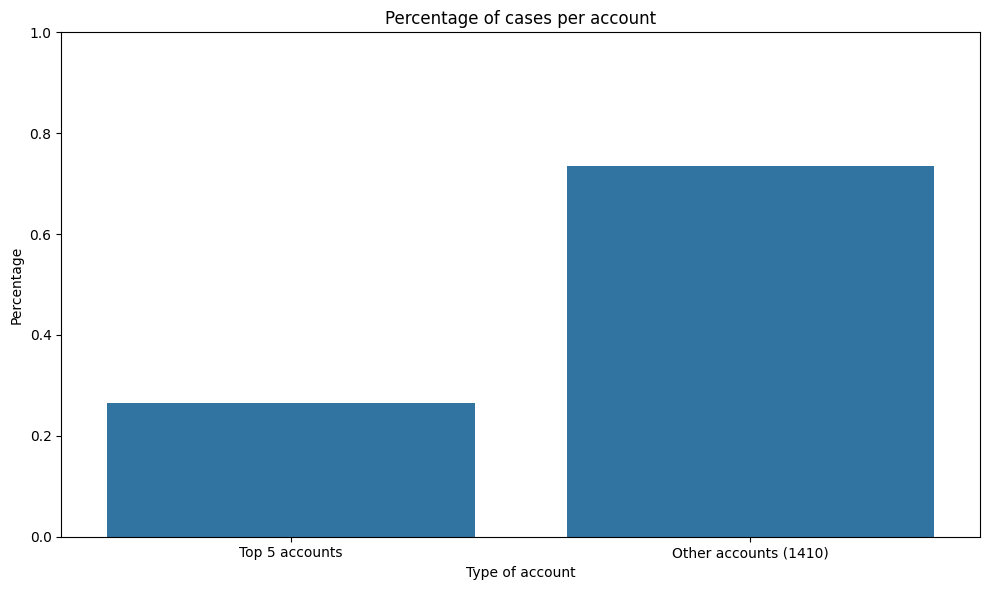

In [65]:
concentration_df = pd.DataFrame({
    'Group': ['Top 5 accounts', 'Other accounts (1410)'],
    'Percentage': [0.264185, 1 - 0.264185]
}
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=concentration_df,
    x='Group',
    y='Percentage'
)

plt.title('Percentage of cases per account')
plt.xlabel('Type of account')
plt.ylabel('Percentage')

plt.ylim(0, 1)
plt.tight_layout()
plt.show()

Overall, the visual analysis reinforces the presence of strong concentration
patterns and performance differences across products and accounts, providing
clear directions for further investigation and potential optimization efforts.

### Part 4: Business insights

### Key insights:

* Support demand is highly concentrated, with approximately 26% of all cases originating from the top five accounts. Notably, the top account alone has over 1,500 known support cases, indicating a potential outlier that requires further investigation.

* A significant number of columns in the support cases dataset contain values such as `Unknown`, `Undefined`, and `Other`. The high prevalence of these values limits the granularity of the analysis and suggests potential data quality or classification issues.

* Support cases are heavily concentrated around the `GVD` product, which may indicate higher product complexity, stability issues, or increased usage compared to other products.

* Most support cases are classified as Low or Medium severity. High and Urgent severity cases are relatively rare. Excluding cases with Undefined severity, all severity levels show close rates above 90%, with Urgent cases achieving a 100% close rate, indicating effective prioritization.

* Accounts are distributed across 72 countries but are highly concentrated in the United States, which accounts for nearly 40% of all accounts. Support cases are also most frequent in the U.S., though the case volume is less disproportionately concentrated than the account distribution.


### Actionable recommendation

* High-volume accounts stood out throughout the analysis. Based on this, it is recommended to implement a strategy focused on the accounts that most frequently request support, identifying root causes and providing dedicated support contacts in order to reduce recurring issues and overall support demand.

* Since certain products are more likely to generate support requests, these products should be investigated more closely to identify potential issues. Improving their stability and overall quality may help reduce the number of support cases while enhancing the customer experience.
